# CHECKPOINT NOTEBOOK — TrackShift Energy System (Design Report)

This notebook is the **FINAL** Approach B then Approach C implementation.

It follows the TrackShift Energy System Design Report exactly.

- Integrals use `get_car_data()` only. Not `get_telemetry()`.
- `EstimatedEnergyIndex` is **simulated / estimated**. It is **not** F1 SOC, ERS, or MGU-K.
- Approach C does **not** create a second battery state.
- ATTACK / SAVE / DEFEND are **not** implemented (CP12 boundary).

`notebooks/01_inspect_race.ipynb` is exploratory / superseded for energy math.

Re-run the full pipeline with:

```
python scripts/run_energy_system.py
```


## Architecture

**APPROACH B**

    get_car_data (original car clock)
        → Δt guards, smoothing, clipped acceleration
        → DeployProxy / HarvestProxy
        → race-state freeze / yellow
        → unscaled D_lap / H_lap
        → alpha / beta calibration
        → EstimatedEnergyIndex in [0, 1]

**APPROACH C**

    Approach B
        + CircuitInfo brake/corner/straight zones
        + 400 m session-baseline lookahead

C informs upcoming demand. B owns energy state.


In [1]:
import json
from pathlib import Path
import pandas as pd

ROOT = Path("..")
cfg = json.loads((ROOT / "outputs" / "energy_config.json").read_text(encoding="utf-8"))
report = json.loads((ROOT / "outputs" / "checkpoint_report.json").read_text(encoding="utf-8"))
proxies = pd.read_csv(ROOT / "data" / "processed" / "australian_gp_2026_lap_energy_proxies.csv")
energy = pd.read_csv(ROOT / "data" / "processed" / "australian_gp_2026_laps_energy_v1.csv")
trackaware = pd.read_csv(ROOT / "data" / "processed" / "australian_gp_2026_laps_energy_trackaware_v1.csv")
zones = pd.read_csv(ROOT / "data" / "processed" / "australian_gp_2026_circuit_zones.csv")
ref = pd.read_csv(ROOT / "outputs" / "reference_lap_samples.csv")
print("proxy rows", len(proxies), "energy rows", len(energy), "trackaware rows", len(trackaware))
print("drivers", energy["Driver"].nunique(), "duplicate Driver+Lap", int(energy.duplicated(["Driver","LapNumber"]).sum()))
print("E0", cfg["e0"], "alpha", cfg["alpha"], "beta", cfg["beta"])
print("NOT_F1_CONSTANTS", cfg["NOT_F1_CONSTANTS"])
print("raw unchanged", report["raw_unchanged"], "clean unchanged", report["clean_unchanged"])


proxy rows 995 energy rows 995 trackaware rows 995
drivers 20 duplicate Driver+Lap 0
E0 1.0 alpha 7.822458038879233e-06 beta 3.689532379100818e-06
NOT_F1_CONSTANTS True
raw unchanged True clean unchanged True


## CP1 — Telemetry extract

NOR lap 5, `get_car_data(pad=1, pad_side='both')`. No `get_telemetry()` in the energy math.


In [1]:
print("CP1 from pipeline log / report")
print("n in-lap window samples:", report["cp1"]["n_in_window"])
print("median dt:", report["cp1"]["median_dt"])
print("throttle 104:", report["cp1"]["throttle_104"])
print("brake dtype:", report["cp1"]["brake_dtype"])
print("Used get_car_data only. Did not use get_telemetry() for integrals.")
print(ref[["Date","Distance","Speed","Throttle","Brake"]].head(5).to_string())


CP1 from pipeline log / report
n in-lap window samples: 328
median dt: 0.24
throttle 104: 0
brake dtype: bool
Used get_car_data only. Did not use get_telemetry() for integrals.


## CP2 — Distance overlay

Distance min/max = `7.046` / `5246.159` m. Monotonic = `True`.


## CP3 — Sample-level proxies (design-report formulas)

- `DeployProxy = v * tau * race_state_factor`
- `HarvestProxy = v * d * 1[Brake and d >= d_min]`
- `d_min = 1.0 m/s²` (modeling choice, not F1)
- Lift-and-coast is **not** harvest

NOR lap 5: mean DeployProxy `39.430`, mean HarvestProxy `97.503`, max harvest when Brake=False `0.0`.


## CP4 — Race-state masking

Freeze if TrackStatus contains 4/5/6/7 or the lap is a box lap. Yellow (contains 2, not freeze) multiplies both proxies by 0.3.

Clean file: `121` freeze-status laps, `61` box laps. Masked example proxies = 0.


## CP5 — All-laps unscaled integrals

Wrote `data/processed/australian_gp_2026_lap_energy_proxies.csv`.

- rows `995`
- duplicates `0`
- thin laps `0`
- sample rows `326048`
- freeze D_lap / H_lap mean 0
- winsorize p995 Deploy `90.2778` (clipped 1544)
- winsorize p995 Harvest `1383.3333` (clipped 1579)


## CP6 — Alpha / beta calibration

Calibration set: green (`TrackStatus==1` only), non-box, `IsAccurate=True`, not thin, not freeze.

- n laps: `829`
- median D_lap: `3835.111656`
- median H_lap: `8131.111728`
- target median |net|: `0.03`
- **alpha = `7.822458038879233e-06`**
- **beta = `3.689532379100818e-06`**
- d_min = `1.0` m/s²
- a clip = `[-20.0, 15.0]` m/s²

**NOT F1 CONSTANTS.** These are simulation scale parameters only. Saved in `outputs/energy_config.json`.


## CP7 — EstimatedEnergyIndex walk

Per driver, sorted by LapNumber. Sample-level update inside the lap. Store end-of-lap E.

- E0 = `1.0` (full estimated budget at race start; not a 2026 SOC rule claim)
- bounds `[0, 1]`
- freeze / pit / SC / VSC / red: hold E
- n scale reductions: `0`
- end-of-lap E min/max: `0.677642` / `0.998090`

Wrote `data/processed/australian_gp_2026_laps_energy_v1.csv`.


## CP8 — Validation pack

Section 18 checks. There is **no** public SOC ground truth, so this is sanity validation, not accuracy vs F1 battery.


In [1]:
print('CP8 validation')
for chk in report['cp8']['checks']:
    print(('PASS' if chk['passed'] else 'FAIL'), chk['name'] + ':', chk['detail'])
print('passed', report['cp8']['passed'], report['cp8']['n_passed'], '/', report['cp8']['n_checks'])


  [PASS] spatial_deploy_harvest: mean DeployProxy on ends=42.1533; mean HarvestProxy mid=109.2398 vs ends=70.3536
  [PASS] harvest_brake_gate: max HarvestProxy when Brake=False: 0.0
  [PASS] pit_sc_vsc_freeze: n freeze laps with previous E=145; max |dE|=0.0
  [PASS] max_dt_used_le_1s: max_dt_used=1.0
  [PASS] energy_bounds: min=0.6776415125149866 max=0.9980897579198108
  [PASS] energy_not_mostly_pegged: fraction of energy samples in (0.05,0.95)=0.201; at 0 or 1=0.016; std=0.05100; range=0.32684
  [PASS] throttle_vs_D_lap: mean per-driver corr(mean_throttle, D_lap) on calibration laps=0.7840303977871391
  [PASS] clean_laps_995: lap_table rows=995
  [PASS] output_rows_995: energy_laps rows=995
  [PASS] zero_duplicate_driver_lap: duplicates=0
  [PASS] label_estimated_energy_index: column is EstimatedEnergyIndex_end (end-of-lap simulated state, not SOC)
  [PASS] raw_unchanged: raw sha256=63f3ef518a0dd082bbebb975a2d39201d0a296f2e699ad07c3e2ceca2b55fb35
  [PASS] clean_unchanged: clean sha256

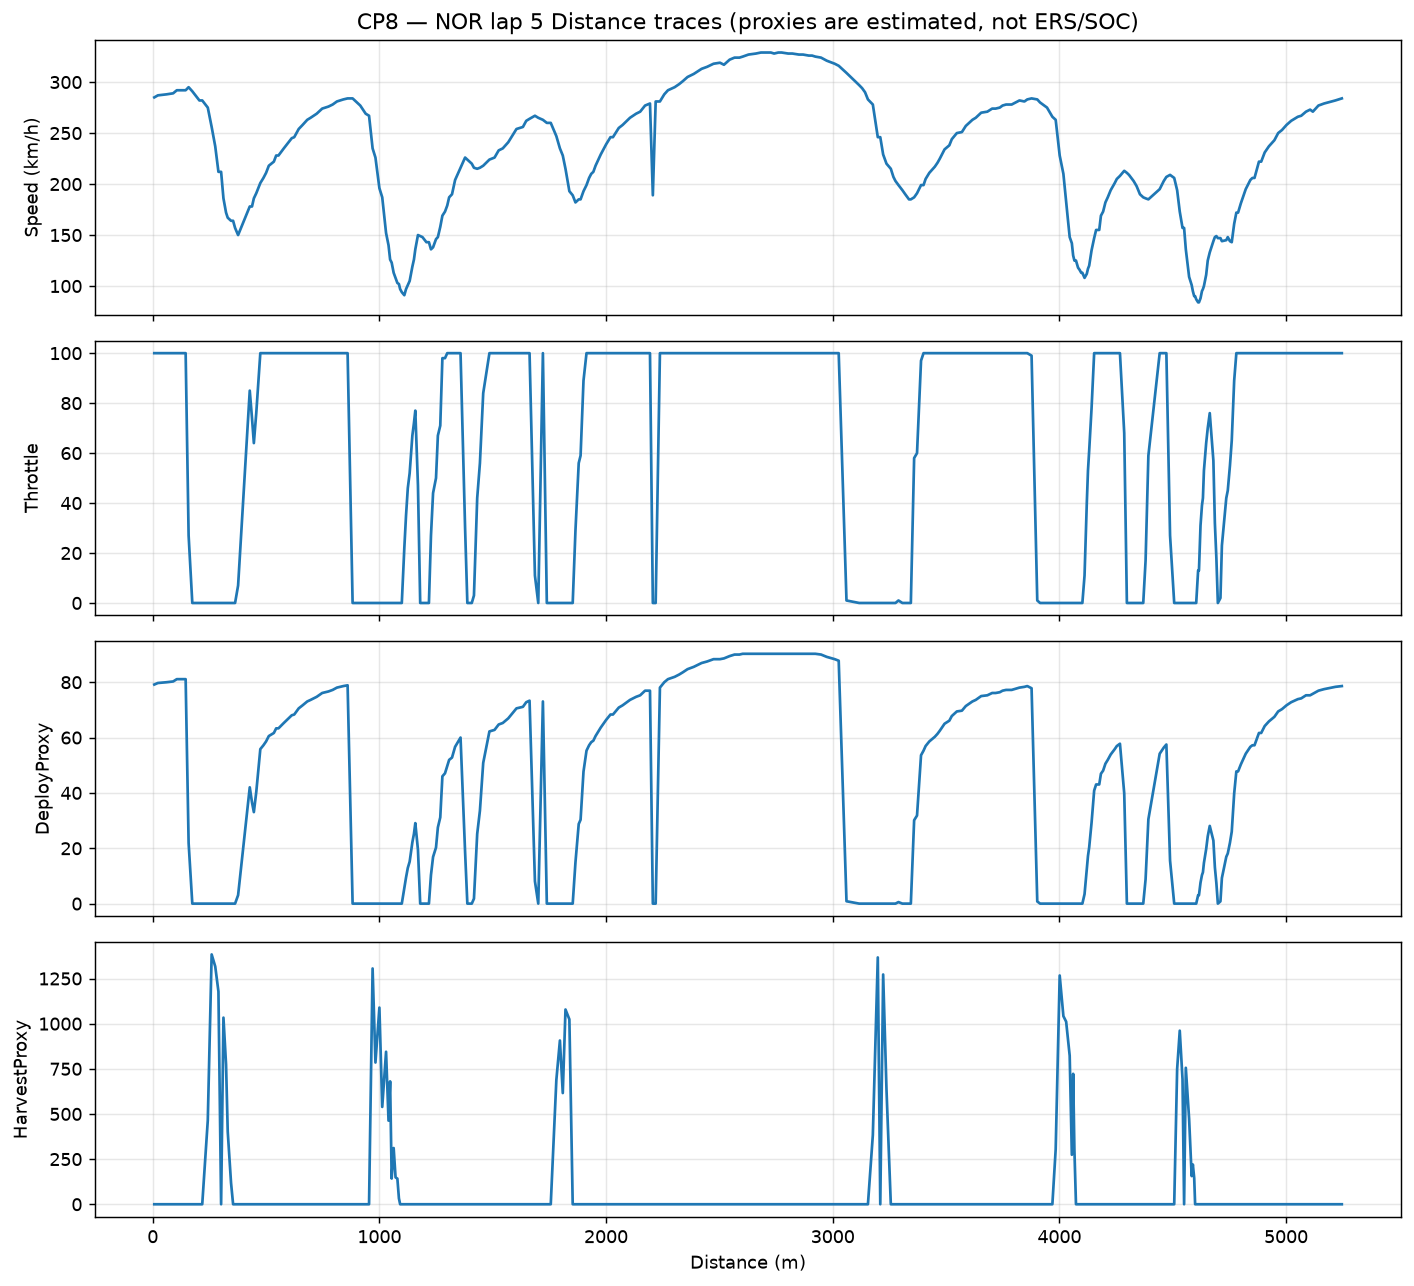

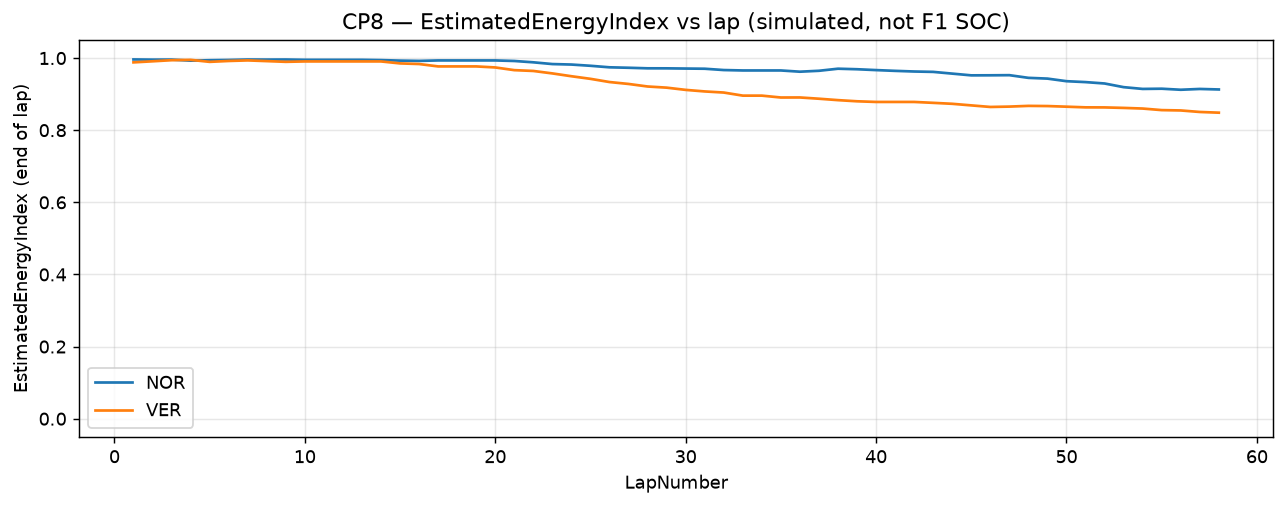

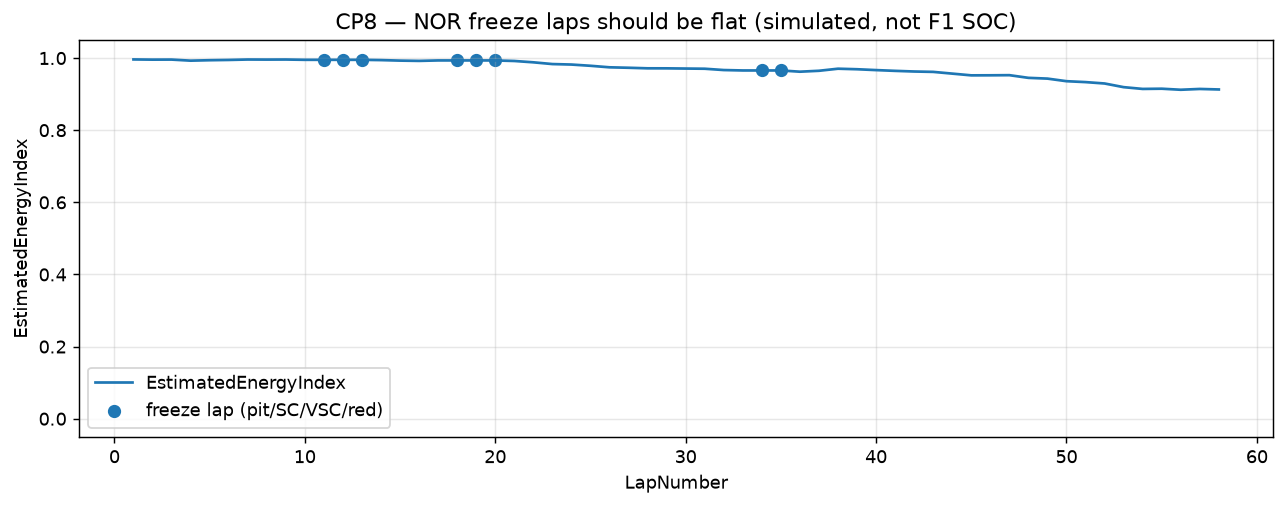

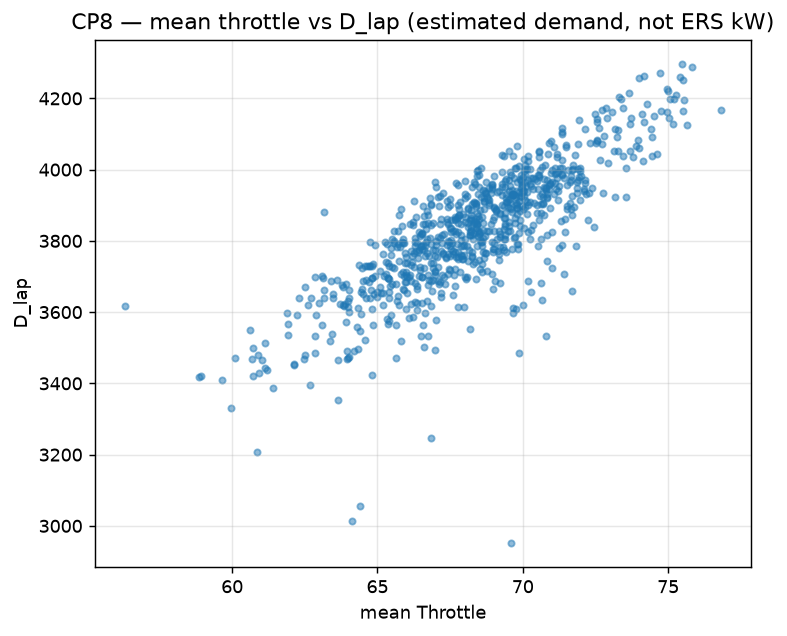

In [1]:
from IPython.display import Image, display
from pathlib import Path
figdir = Path("../outputs/figures")
for name in [
    "cp8_reference_deploy_harvest.png",
    "cp8_two_driver_energy.png",
    "cp8_freeze_energy.png",
    "cp8_throttle_vs_dlap.png",
]:
    display(Image(filename=str(figdir / name)))


## CP9 — CircuitInfo zones (Approach C starts)

Offsets: brake `[corner-150, corner-30)`, corner `[corner-30, corner+30)`, remainder straight.

- n zones: `37`
- track length: `5465.506` m
- coverage gap: 0
- types: `{'brake': 14, 'corner': 14, 'straight': 9}`

Wrote `data/processed/australian_gp_2026_circuit_zones.csv`.


In [1]:
print(zones.to_string(index=False))
print("n zones", len(zones), "coverage m", float(zones["length_m"].sum()))


zone table printed from data/processed/australian_gp_2026_circuit_zones.csv


## CP10 — Zone baselines + 400 m lookahead

Baselines from the calibration set (session typical flying-lap demand, not the current noisy sample).

Labels: `LookaheadDeployProxy` / `LookaheadHarvestProxy`.

Longest straight `straight_05` length `941.9556898886449`.

Wrote `data/processed/australian_gp_2026_laps_energy_trackaware_v1.csv`.

No second SOC/energy model.


## CP11 — Visual demo slice

Every energy title: **Estimated / simulated; not F1 SOC**.


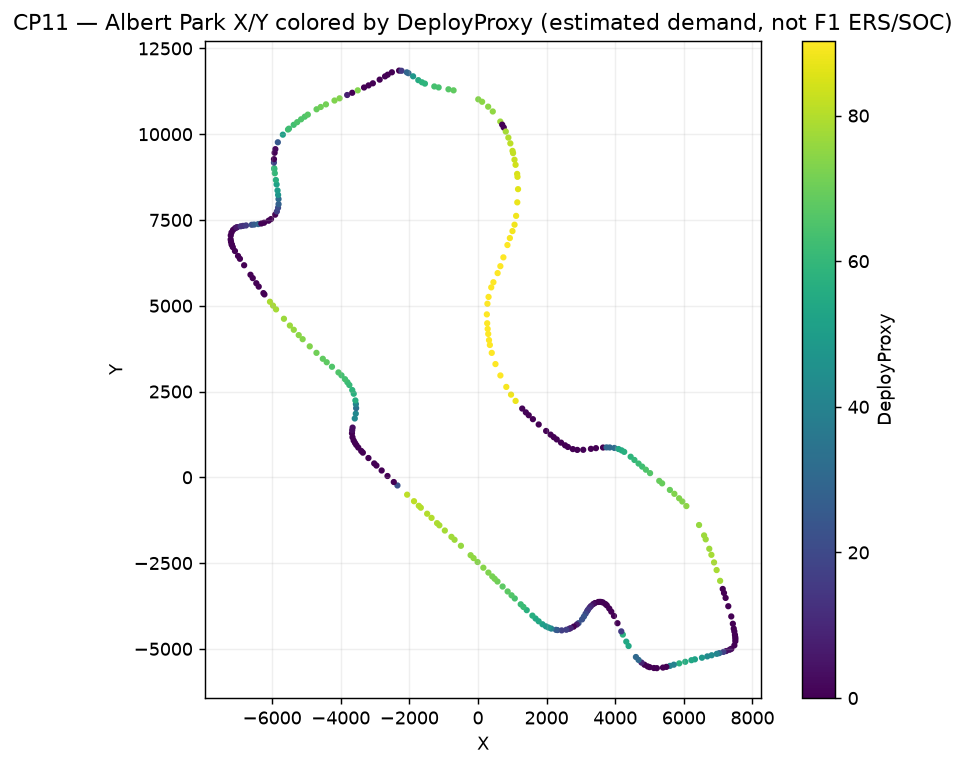

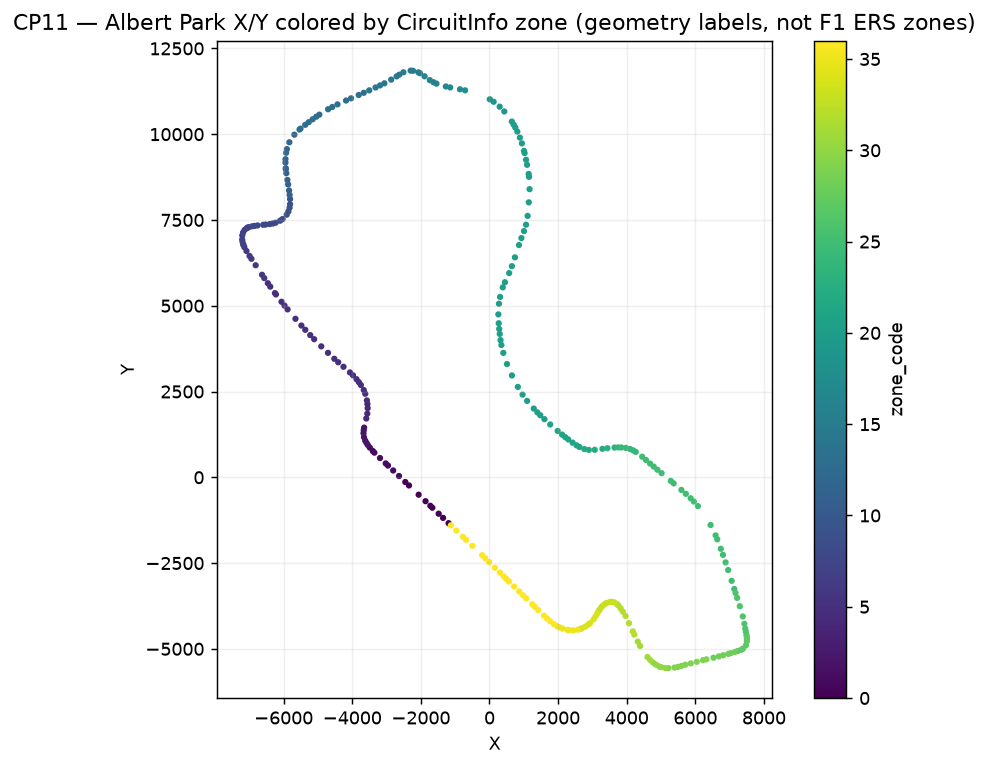

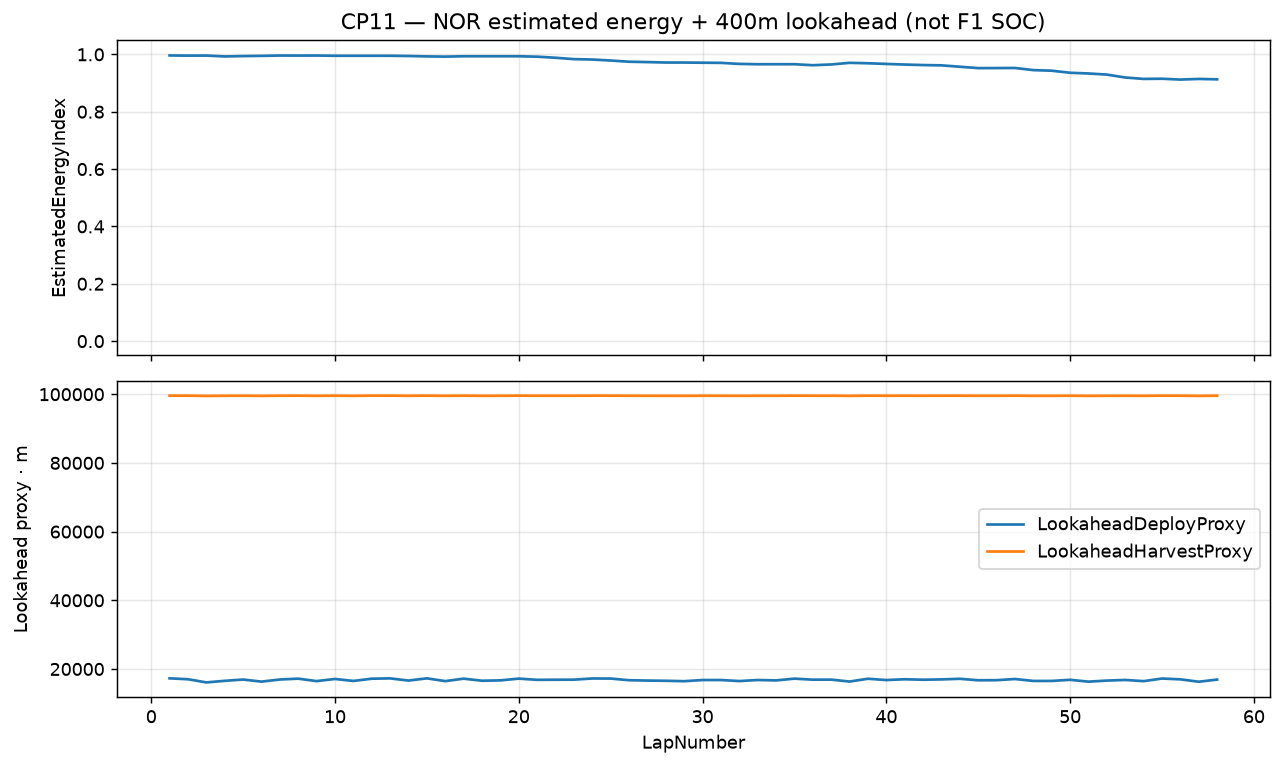

In [1]:
from IPython.display import Image, display
from pathlib import Path
figdir = Path("../outputs/figures")
for name in [
    "cp11_track_map_deploy.png",
    "cp11_track_map_zones.png",
    "cp11_energy_lookahead.png",
]:
    display(Image(filename=str(figdir / name)))


## CP12 — Stop / strategy boundary

Completed foundation:

- Approach B estimated energy state
- Approach C track zones + 400 m lookahead

**Not implemented (intentionally):** ATTACK / SAVE / DEFEND, gap-to-ahead, driver-ahead, official ERS maps.

Next design phase (not this execution): combine `EstimatedEnergyIndex`, lookahead, and later overtaking features.
